# NYC Yellow Taxi Tip Prediction — COMP 3610 Big Data Analytics

## Project Overview
This notebook predicts tip amounts for NYC yellow taxi trips (January 2024). It covers data ingestion, cleaning, feature engineering, regression and classification modelling, hyperparameter tuning, cross-validation, and a PyTorch neural network.

**Prediction tasks:**
- Regression: predict `tip_amount` (continuous)
- Classification: predict `high_tip` (1 if tip > 20% of fare, else 0)

**Design decision:** Only credit card transactions (`payment_type=1`) are used because tip amounts are only reliably recorded for card payments. Cash trips report `tip_amount=0` by default and would introduce systematic bias.

---

## Data Ingestion & Storage

In [2]:
import requests
import os
import pandas as pd
import polars as pl
import duckdb
import numpy as np
import time

pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(10000)

try:
    # 1. Programmatic download and file organisation
    def download_file(url):
        os.makedirs('data/raw', exist_ok=True)
        filename = 'data/raw/' + url.split('/')[-1]
        with requests.get(url, stream=True) as reference:
            reference.raise_for_status()
            with open(filename, 'wb') as f:
                for chunk in reference.iter_content(chunk_size=8192):
                    f.write(chunk)
        return filename

    parquetfile = download_file(
        'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet'
    )
    csvfile = download_file(
        'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'
    )

    lazy_parquetfile = pl.scan_parquet(parquetfile)
    lazy_csvfile = pl.scan_csv(csvfile)

    df_csvfile = lazy_csvfile.collect()
    df_polars = lazy_parquetfile.collect()

    # Join borough names onto pickup and dropoff location IDs
    df_polars = df_polars.join(
        df_csvfile.select(['LocationID', 'Borough']).rename({'Borough': 'pickup_borough'}),
        left_on='PULocationID',
        right_on='LocationID',
        how='left'
    ).join(
        df_csvfile.select(['LocationID', 'Borough']).rename({'Borough': 'dropoff_borough'}),
        left_on='DOLocationID',
        right_on='LocationID',
        how='left'
    )

    # 2. Filter: credit card payments only
    # tip_amount is only reliably recorded for credit card transactions (payment_type=1).
    # Cash trips record tip_amount=0 by default and must be excluded to avoid bias.
    before = df_polars.shape[0]
    df_polars = df_polars.filter(pl.col('payment_type') == 1)
    after = df_polars.shape[0]
    print(f'Before credit card filter : {before:,} rows')
    print(f'After  credit card filter : {after:,} rows')
    print(f'Removed                   : {before - after:,} rows '
          f'({(before - after) / before * 100:.1f}% non-credit card)')

    # 3. Data validation
    required_columns = [
        'tpep_pickup_datetime', 'tpep_dropoff_datetime',
        'PULocationID', 'DOLocationID',
        'passenger_count', 'trip_distance',
        'fare_amount', 'tip_amount', 'total_amount', 'payment_type'
    ]

    missing_columns = [c for c in required_columns if c not in df_polars.columns]

    if not missing_columns:
        print('All required columns are present.')
    else:
        print('Some required columns are missing:', missing_columns)
        exit(1)

    for col in df_polars.columns:
        if 'datetime' in col:
            if df_polars[col].dtype != pl.Datetime:
                print(f"Column '{col}' is not in datetime format.")
                exit(1)

    print('All datetime columns are in the correct format.')
    print(f'Row count after filtering: {df_polars.height:,}')

except Exception as e:
    print(f'An error occurred validating the data: {e}')
    exit(1)

Before credit card filter : 2,964,624 rows
After  credit card filter : 2,319,046 rows
Removed                   : 645,578 rows (21.8% non-credit card)
All required columns are present.
All datetime columns are in the correct format.
Row count after filtering: 2,319,046


### Approach

Data is loaded using Polars lazy evaluation for efficiency, then collected after joins:

- **Trip data:** NYC yellow taxi trips for January 2024 (Parquet, TLC website)
- **Zone lookup:** Maps `PULocationID`/`DOLocationID` to borough names

Both files are joined on `LocationID` before feature engineering. Only credit card trips (`payment_type=1`) are retained at ingestion time.

### Observations

- Approximately 2 million credit card trip records loaded after filtering
- All required columns present with correct data types
- Datetime columns properly formatted for time-based feature extraction

---

## Part 1: Data Preprocessing & Feature Engineering

### Data Cleaning

In [3]:
rows = df_polars.height

# Remove rows with null values in critical fields
filtered_df = df_polars.filter(
    (pl.col('tpep_pickup_datetime').is_not_null()) &
    (pl.col('tpep_dropoff_datetime').is_not_null()) &
    (pl.col('PULocationID').is_not_null()) &
    (pl.col('DOLocationID').is_not_null()) &
    (pl.col('fare_amount').is_not_null())
).select(pl.all())

removed_nulls = rows - filtered_df.height
print(f'Rows removed due to null values: {removed_nulls}')

prev = filtered_df.height

# Remove invalid fare and distance values
filtered_df = filtered_df.filter(
    (pl.col('trip_distance') > 0) &
    (pl.col('fare_amount') >= 0) &
    (pl.col('fare_amount') <= 500)
).select(pl.all())

removed_invalid = prev - filtered_df.height
print(f'Rows removed due to invalid fares or distances: {removed_invalid}')

prev = filtered_df.height

# Remove trips where pickup time is not before dropoff time
filtered_df = filtered_df.filter(
    pl.col('tpep_pickup_datetime') < pl.col('tpep_dropoff_datetime')
).select(pl.all())

removed_temporal = prev - filtered_df.height
print(f'Rows removed due to invalid timestamps: {removed_temporal}')
print(f'Final row count: {filtered_df.height:,}')

Rows removed due to null values: 0
Rows removed due to invalid fares or distances: 20626
Rows removed due to invalid timestamps: 41
Final row count: 2,298,379


#### Cleaning Strategy

Four filters are applied in sequence:

**Null value filtering:** Records with missing pickup/dropoff times, location IDs, or fare amounts are removed before any computation.

**Invalid fare/distance filtering:** Fares above $500 and zero-distance trips are excluded as data entry errors not representative of genuine journeys.

**Temporal validation:** Trips where pickup time is on or after dropoff time are physically impossible and are removed.

**Credit card filter** (applied at ingestion): Only `payment_type=1` records are retained so that `tip_amount` values are reliable.

### 1. Feature Engineering

In [ ]:
# a) Temporal features
engineered = filtered_df.with_columns([
    # Hour of day (0-23)
    pl.col('tpep_pickup_datetime').dt.hour().alias('pickup_hour'),

    # Day of week using ISO weekday (1=Mon, 7=Sun) shifted to 0-indexed
    ((pl.col('tpep_pickup_datetime').dt.weekday() - 1) % 7).alias('pickup_day_of_week'),

    # Weekend flag: True if not a business day
    (~pl.col('tpep_pickup_datetime').dt.is_business_day()).alias('is_weekend'),
])

# b) Trip features
engineered = engineered.with_columns([
    # Trip duration in minutes
    ((pl.col('tpep_dropoff_datetime') - pl.col('tpep_pickup_datetime')).dt.total_seconds() / 60).alias('trip_duration_minutes'),

    # Trip speed in miles per hour
    (pl.col('trip_distance') * 3600 /
     (pl.col('tpep_dropoff_datetime') - pl.col('tpep_pickup_datetime')).dt.total_seconds()).alias('trip_speed_mph'),

    # Log-transformed trip distance to reduce right skew
    pl.col('trip_distance').log().alias('log_trip_distance'),
])

# c) Fare features — replace(0, None) guards against division by zero
engineered = engineered.with_columns([
    (pl.col('fare_amount') / pl.col('trip_distance').replace(0, None)).alias('fare_per_mile'),
    (pl.col('fare_amount') / pl.col('trip_duration_minutes').replace(0, None)).alias('fare_per_minute'),
])

# d) Borough one-hot encoding (pickup and dropoff)
engineered = engineered.to_dummies(columns=['pickup_borough', 'dropoff_borough'])

print(f'Engineered dataframe shape: {engineered.shape}')
print(engineered.head(3))

Engineered dataframe shape: (2298379, 43)
shape: (3, 43)
┌──────────┬──────────────────────┬───────────────────────┬─────────────────┬───────────────┬────────────┬────────────────────┬──────────────┬──────────────┬──────────────┬─────────────┬───────┬─────────┬────────────┬──────────────┬───────────────────────┬──────────────┬──────────────────────┬─────────────┬──────────────────────┬─────────────────────────┬────────────────────┬──────────────────────────┬────────────────────┬───────────────────────┬──────────────────────────────┬────────────────────────┬───────────────────────┬──────────────────────────┬─────────────────────┬───────────────────────────┬─────────────────────┬────────────────────────┬───────────────────────────────┬─────────────────────────┬─────────────┬────────────────────┬────────────┬───────────────────────┬────────────────┬───────────────────┬───────────────┬─────────────────┐
│ VendorID ┆ tpep_pickup_datetime ┆ tpep_dropoff_datetime ┆ passenger_count ┆ trip_dist

#### Observations

- `pickup_hour` and `pickup_day_of_week` capture demand cycles
- `is_weekend` groups Saturday/Sunday separately from weekday patterns
- `trip_duration_minutes` and `trip_speed_mph` are derived from datetime differences
- `log_trip_distance` reduces right skew in the distance distribution
- `fare_per_mile` and `fare_per_minute` use `replace(0, None)` to avoid division by zero
- Borough columns are one-hot encoded into 16 indicator columns (8 pickup + 8 dropoff)

#### Preprocessing

In [5]:
# Replace any remaining string '?' values with null
engineered = engineered.with_columns([
    pl.col(pl.String).replace('?', None)
])

# Drop raw datetime and ID columns no longer needed after feature extraction
cols_to_drop = [
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'store_and_fwd_flag',
    'PULocationID',
    'DOLocationID',
]
engineered = engineered.drop([c for c in cols_to_drop if c in engineered.columns])

# Fill remaining nulls with 0
engineered = engineered.fill_null(0)

print(f'Final engineered shape: {engineered.shape}')

Final engineered shape: (2298379, 38)


### 2. Target Variable Creation

In [ ]:
# Binary high_tip label: 1 if tip exceeds 20% of fare, else 0
engineered = engineered.with_columns([
    (pl.col('tip_amount') > (pl.col('fare_amount') * 0.20)).cast(pl.Int8).alias('high_tip')
])

engineered.select(['fare_amount', 'tip_amount', 'high_tip']).head(10)

fare_amount,tip_amount,high_tip
f64,f64,i8
10.0,3.75,1
23.3,3.0,0
10.0,2.0,0
7.9,3.2,1
29.6,6.9,1
45.7,10.0,1
7.9,0.0,0
14.9,3.95,1
59.0,14.15,1


### 3. Data Splitting & Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_pd = engineered.to_pandas()

# Cast boolean is_weekend to integer for sklearn compatibility
df_pd['is_weekend'] = df_pd['is_weekend'].astype(int)

X = df_pd.drop(columns=['tip_amount', 'high_tip'])
y = df_pd['high_tip']

# Stratified 70 / 15 / 15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Drop total_amount after splitting to prevent data leakage
# (total_amount = fare + tip + extras, which directly encodes the target)
X_train = X_train.drop(columns=['total_amount'], errors='ignore')
X_val = X_val.drop(columns=['total_amount'], errors='ignore')
X_test = X_test.drop(columns=['total_amount'], errors='ignore')

# Scale numeric features — fit on training set only to prevent leakage
numeric_cols = [
    'trip_distance', 'fare_amount', 'extra', 'mta_tax',
    'tolls_amount', 'improvement_surcharge',
    'congestion_surcharge', 'Airport_fee',
    'fare_per_mile', 'fare_per_minute',
    'trip_duration_minutes',
]

scaler = StandardScaler()
scaler.fit(X_train[numeric_cols])

X_train[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

total = len(df_pd)
splits = {
    'Train': (X_train, y_train),
    'Validation': (X_val, y_val),
    'Test': (X_test, y_test),
}

print('=' * 75)
print(f"{'SPLIT SUMMARY':^75}")
print('=' * 75)
print(f"{'Split':<12} {'Samples':>10} {'% of Total':>12} " f"{'high_tip=0':>12} {'high_tip=1':>12} {'Tip Rate':>10}")
print('-' * 75)

for name, (X, y) in splits.items():
    n = len(y)
    pct = n / total * 100
    n_zeros = (y == 0).sum()
    n_ones = (y == 1).sum()
    tip_rate = y.mean() * 100
    print(f"{name:<12} {n:>10,} {pct:>11.1f}% " f"{n_zeros:>12,} {n_ones:>12,} {tip_rate:>9.1f}%")

print('=' * 75)
print(f"{'TOTAL':<12} {total:>10,} {'100.0%':>12}")

                               SPLIT SUMMARY                               
Split           Samples   % of Total   high_tip=0   high_tip=1   Tip Rate
---------------------------------------------------------------------------
Train         1,608,865        70.0%      387,217    1,221,648      75.9%
Validation      344,757        15.0%       82,975      261,782      75.9%
Test            344,757        15.0%       82,975      261,782      75.9%
TOTAL         2,298,379       100.0%


#### d) Summary

In [8]:
# Document included and excluded features
feature_summary = pd.DataFrame({
    'Feature': X_train.columns.tolist(),
    'Dtype': X_train.dtypes.astype(str).tolist(),
    'Status': 'Included'
})

excluded = pd.DataFrame([
    {'Feature': 'tip_amount',
     'Dtype': 'f64', 'Status': 'Excluded',
     'Reason': 'Regression target variable'},
    {'Feature': 'high_tip',
     'Dtype': 'i8', 'Status': 'Excluded',
     'Reason': 'Classification target variable'},
    {'Feature': 'tpep_pickup_datetime',
     'Dtype': 'datetime', 'Status': 'Excluded',
     'Reason': 'Raw datetime replaced by engineered time features'},
    {'Feature': 'tpep_dropoff_datetime',
     'Dtype': 'datetime', 'Status': 'Excluded',
     'Reason': 'Raw datetime replaced by engineered time features'},
    {'Feature': 'total_amount',
     'Dtype': 'f64', 'Status': 'Excluded',
     'Reason': 'Leaks the target (total_amount includes tip_amount)'},
    {'Feature': 'store_and_fwd_flag',
     'Dtype': 'str', 'Status': 'Excluded',
     'Reason': 'Low-signal Y/N flag, not useful for tip prediction'},
])

print('=' * 60)
print(f"{'INCLUDED FEATURES':^60}")
print('=' * 60)
print(f"{'#':<5} {'Feature':<30} {'Dtype':<15} {'Status'}")
print('-' * 60)
for i, row in feature_summary.iterrows():
    print(f"{i+1:<5} {row['Feature']:<30} {row['Dtype']:<15} {row['Status']}")

print()
print('=' * 60)
print(f"{'EXCLUDED FEATURES':^60}")
print('=' * 60)
print(f"{'Feature':<30} {'Reason'}")
print('-' * 60)
for _, row in excluded.iterrows():
    print(f"{row['Feature']:<30} {row['Reason']}")

print()
print(f'  Total features included : {len(feature_summary)}')
print(f'  Total features excluded : {len(excluded)}')

                     INCLUDED FEATURES                      
#     Feature                        Dtype           Status
------------------------------------------------------------
1     VendorID                       int32           Included
2     passenger_count                int64           Included
3     trip_distance                  float64         Included
4     RatecodeID                     int64           Included
5     payment_type                   int64           Included
6     fare_amount                    float64         Included
7     extra                          float64         Included
8     mta_tax                        float64         Included
9     tolls_amount                   float64         Included
10    improvement_surcharge          float64         Included
11    congestion_surcharge           float64         Included
12    Airport_fee                    float64         Included
13    pickup_borough_Bronx           uint8           Included
14    pickup

---

## Part 2: Model Training & Evaluation

### 4. Baseline Models

#### a) Regression

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Regression targets — tip_amount, separate from the classification labels
y_train_reg = df_pd.loc[X_train.index, 'tip_amount']
y_val_reg = df_pd.loc[X_val.index, 'tip_amount']
y_test_reg = df_pd.loc[X_test.index, 'tip_amount']

# Train Linear Regression
print('Training Linear Regression...')
start = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train_reg)
print(f'Done in {time.time() - start:.1f}s')

# Train Random Forest Regressor
print('Training Random Forest Regressor...')
start = time.time()
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_samples=0.3
)
rf.fit(X_train, y_train_reg)
print(f'Done in {time.time() - start:.1f}s')

# Evaluate on validation set
def evaluate_regressor(name, model, X, y):
    preds = model.predict(X)
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    r2 = r2_score(y, preds)
    print(f'\n{name}')
    print(f'  MAE  : ${mae:.4f}  (average dollar error)')
    print(f'  RMSE : ${rmse:.4f}  (penalises large errors more)')
    print(f'  R2   : {r2:.4f}  (1.0 = perfect, 0 = no better than mean)')

print('=' * 50)
print('       REGRESSION — VALIDATION SET')
print('=' * 50)
evaluate_regressor('Linear Regression', lr, X_val, y_val_reg)
evaluate_regressor('Random Forest Regressor', rf, X_val, y_val_reg)

Training Linear Regression...
Done in 2.1s
Training Random Forest Regressor...
Done in 165.5s
       REGRESSION — VALIDATION SET

Linear Regression
  MAE  : $1.2091  (average dollar error)
  RMSE : $2.3877  (penalises large errors more)
  R2   : 0.6177  (1.0 = perfect, 0 = no better than mean)

Random Forest Regressor
  MAE  : $1.2168  (average dollar error)
  RMSE : $2.3895  (penalises large errors more)
  R2   : 0.6172  (1.0 = perfect, 0 = no better than mean)


#### b) Classification

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# Logistic Regression baseline
log_reg = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)
log_reg.fit(X_train, y_train)

# Random Forest Classifier
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_samples=0.3
)
rf_clf.fit(X_train, y_train)

# Evaluate on validation set
def evaluate_classifier(name, model, X, y):
    preds = model.predict(X)
    print(f'\n{name}')
    print(f'  Accuracy  : {accuracy_score(y, preds):.4f}')
    print(f'  Precision : {precision_score(y, preds):.4f}')
    print(f'  Recall    : {recall_score(y, preds):.4f}')
    print(f'  F1 Score  : {f1_score(y, preds):.4f}')
    print(f'\n  Full Report:\n'
          f'{classification_report(y, preds, target_names=["low_tip", "high_tip"])}')

print('=' * 50)
print('       CLASSIFICATION — VALIDATION SET')
print('=' * 50)
evaluate_classifier('Logistic Regression', log_reg, X_val, y_val)
evaluate_classifier('Random Forest Classifier', rf_clf, X_val, y_val)

c:\Users\Jonathan\OneDrive\Documents\University of the West Indies\Year 3\Semester 2\COMP 3610 Big Data\Assignments\Assignment#2\Comp3610BIgDataAssignment2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


       CLASSIFICATION — VALIDATION SET

Logistic Regression
  Accuracy  : 0.7709
  Precision : 0.7691
  Recall    : 0.9978
  F1 Score  : 0.8687

  Full Report:
              precision    recall  f1-score   support

     low_tip       0.89      0.06      0.10     82975
    high_tip       0.77      1.00      0.87    261782

    accuracy                           0.77    344757
   macro avg       0.83      0.53      0.49    344757
weighted avg       0.80      0.77      0.68    344757


Random Forest Classifier
  Accuracy  : 0.7672
  Precision : 0.7705
  Recall    : 0.9876
  F1 Score  : 0.8656

  Full Report:
              precision    recall  f1-score   support

     low_tip       0.65      0.07      0.13     82975
    high_tip       0.77      0.99      0.87    261782

    accuracy                           0.77    344757
   macro avg       0.71      0.53      0.50    344757
weighted avg       0.74      0.77      0.69    344757



#### c) Performance Report

In [11]:
# Regression summary
def eval_reg(name, model, X, y):
    preds = model.predict(X)
    return {
        'Model': name,
        'MAE': mean_absolute_error(y, preds),
        'RMSE': np.sqrt(mean_squared_error(y, preds)),
        'R2': r2_score(y, preds)
    }

reg_results = [
    eval_reg('Linear Regression', lr, X_val, y_val_reg),
    eval_reg('Random Forest Regressor', rf, X_val, y_val_reg),
]

print('=' * 60)
print(f"{'REGRESSION RESULTS (Validation Set)':^60}")
print('=' * 60)
print(f"{'Model':<30} {'MAE':>8} {'RMSE':>8} {'R2':>8}")
print('-' * 60)
for r in reg_results:
    print(f"{r['Model']:<30} ${r['MAE']:>6.4f} ${r['RMSE']:>6.4f} {r['R2']:>8.4f}")
print('=' * 60)

# Classification summary
def eval_clf(name, model, X, y):
    preds = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y, preds),
        'Precision': precision_score(y, preds, zero_division=0),
        'Recall': recall_score(y, preds, zero_division=0),
        'F1': f1_score(y, preds, zero_division=0),
        'AUC-ROC': roc_auc_score(y, proba)
    }

clf_results = [
    eval_clf('Logistic Regression', log_reg, X_val, y_val),
    eval_clf('Random Forest Classifier', rf_clf, X_val, y_val),
]

print(f"\n{'CLASSIFICATION RESULTS (Validation Set)':^60}")
print('=' * 60)
print(f"{'Model':<30} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'AUC':>6}")
print('-' * 60)
for r in clf_results:
    print(f"{r['Model']:<30} {r['Accuracy']:>6.4f} {r['Precision']:>6.4f} "
          f"{r['Recall']:>6.4f} {r['F1']:>6.4f} {r['AUC-ROC']:>6.4f}")
print('=' * 60)

print('\nMetric guide:')
print('  MAE / RMSE   lower is better; RMSE penalises large errors more heavily')
print('  R2           proportion of tip variance explained (1.0 = perfect)')
print('  AUC-ROC      class separation ability (0.5 = random, 1.0 = perfect)')
print('  F1           harmonic mean of precision and recall')

            REGRESSION RESULTS (Validation Set)             
Model                               MAE     RMSE       R2
------------------------------------------------------------
Linear Regression              $1.2091 $2.3877   0.6177
Random Forest Regressor        $1.2168 $2.3895   0.6172

          CLASSIFICATION RESULTS (Validation Set)           
Model                             Acc   Prec    Rec     F1    AUC
------------------------------------------------------------
Logistic Regression            0.7709 0.7691 0.9978 0.8687 0.6089
Random Forest Classifier       0.7672 0.7705 0.9876 0.8656 0.5889

Metric guide:
  MAE / RMSE   lower is better; RMSE penalises large errors more heavily
  R2           proportion of tip variance explained (1.0 = perfect)
  AUC-ROC      class separation ability (0.5 = random, 1.0 = perfect)
  F1           harmonic mean of precision and recall


### 5. Hyperparameter Tuning

`RandomizedSearchCV` with `n_iter=20` is used to search over the parameter space of the Random Forest Classifier. A 20% stratified sample of the training data is used to keep runtimes manageable, as required by the assignment specification. Scoring metric is AUC-ROC; cross-validation uses 3 folds.

#### a) RandomizedSearchCV

In [12]:
from sklearn.model_selection import RandomizedSearchCV

# Search space covering 3+ hyperparameters
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.3],
}

# 20% stratified sample — documented as required by assignment spec
X_train_sample = X_train.sample(frac=0.2, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]
print(f'Tuning sample size: {len(X_train_sample):,} rows '
      f'({len(X_train_sample) / len(X_train) * 100:.0f}% of training set)')

# RandomizedSearchCV with n_iter=20 as required
rf_tuned = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        max_samples=0.3,
        class_weight='balanced'
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=2
)

print('Starting hyperparameter search...')
start = time.time()
rf_tuned.fit(X_train_sample, y_train_sample)
print(f'Done in {time.time() - start:.1f}s')

print()
print('=' * 50)
print('        BEST HYPERPARAMETERS FOUND')
print('=' * 50)
for param, value in rf_tuned.best_params_.items():
    print(f'  {param:<25} {value}')
print(f'\n  Best CV AUC-ROC: {rf_tuned.best_score_:.4f}')
print('=' * 50)

best_model = rf_tuned.best_estimator_

# Evaluate tuned model on validation set
preds = best_model.predict(X_val)
proba = best_model.predict_proba(X_val)[:, 1]

print(f"\n{'TUNED MODEL — VALIDATION RESULTS':^50}")
print('=' * 50)
print(f'  Accuracy  : {accuracy_score(y_val, preds):.4f}')
print(f'  Precision : {precision_score(y_val, preds):.4f}')
print(f'  Recall    : {recall_score(y_val, preds):.4f}')
print(f'  F1        : {f1_score(y_val, preds):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_val, proba):.4f}')
print('=' * 50)

Tuning sample size: 321,773 rows (20% of training set)
Starting hyperparameter search...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END max_depth=None, max_features=0.3, min_samples_leaf=4, min_samples_split=5, n_estimators=50; total time=  14.8s
[CV] END max_depth=None, max_features=0.3, min_samples_leaf=4, min_samples_split=5, n_estimators=50; total time=  14.3s
[CV] END max_depth=None, max_features=0.3, min_samples_leaf=4, min_samples_split=5, n_estimators=50; total time=  14.8s
[CV] END max_depth=10, max_features=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  47.8s
[CV] END max_depth=10, max_features=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  48.2s
[CV] END max_depth=10, max_features=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  48.7s
[CV] END max_depth=20, max_features=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  12.9s
[CV] END max_de

#### b) 5-Fold Cross-Validation

5-fold stratified cross-validation is run on the best model using a 300,000-row sample of the training set. `n_jobs=1` is used to avoid memory errors on large datasets.

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Stratified sample of 300,000 rows
sample_size = 300_000
X_cv = X_train.sample(n=sample_size, random_state=42)
y_cv = y_train.loc[X_cv.index]

print(f'CV sample size : {len(X_cv):,} rows')
print(f'high_tip rate  : {y_cv.mean():.3f} '
      f'(original training rate: {y_train.mean():.3f})')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'auc_roc': 'roc_auc',
}

print('\nRunning 5-fold cross-validation...')
start = time.time()

cv_results = cross_validate(
    best_model,
    X_cv, y_cv,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    verbose=1,
    return_train_score=False
)

print(f'Done in {time.time() - start:.1f}s')

print()
print('=' * 60)
print(f"{'5-FOLD CROSS-VALIDATION RESULTS (Random Forest)':^60}")
print('=' * 60)
print(f"{'Metric':<15} {'Fold 1':>8} {'Fold 2':>8} {'Fold 3':>8} "
      f"{'Fold 4':>8} {'Fold 5':>8} {'Mean':>8} {'Std':>8}")
print('-' * 60)

metrics_map = {
    'Accuracy': 'test_accuracy',
    'Precision': 'test_precision',
    'Recall': 'test_recall',
    'F1': 'test_f1',
    'AUC-ROC': 'test_auc_roc',
}

for label, key in metrics_map.items():
    scores = cv_results[key]
    fold_str = ''.join([f'{s:>8.4f}' for s in scores])
    print(f'{label:<15}{fold_str} {scores.mean():>8.4f} {scores.std():>8.4f}')

print('=' * 60)
print(f'\n  Mean F1      : {cv_results["test_f1"].mean():.4f} '
      f'+/- {cv_results["test_f1"].std():.4f}')
print(f'  Mean AUC-ROC : {cv_results["test_auc_roc"].mean():.4f} '
      f'+/- {cv_results["test_auc_roc"].std():.4f}')
print('\n  Std < 0.01 indicates a stable, consistent model across folds.')

CV sample size : 300,000 rows
high_tip rate  : 0.760 (original training rate: 0.759)

Running 5-fold cross-validation...
Done in 127.6s

      5-FOLD CROSS-VALIDATION RESULTS (Random Forest)       
Metric            Fold 1   Fold 2   Fold 3   Fold 4   Fold 5     Mean      Std
------------------------------------------------------------
Accuracy         0.6029  0.6094  0.6040  0.6048  0.6082   0.6059   0.0025
Precision        0.8105  0.8112  0.8122  0.8121  0.8126   0.8117   0.0007
Recall           0.6234  0.6337  0.6233  0.6248  0.6300   0.6270   0.0041
F1               0.7048  0.7115  0.7053  0.7062  0.7097   0.7075   0.0026
AUC-ROC          0.6144  0.6218  0.6235  0.6199  0.6221   0.6203   0.0032

  Mean F1      : 0.7075 +/- 0.0026
  Mean AUC-ROC : 0.6203 +/- 0.0032

  Std < 0.01 indicates a stable, consistent model across folds.


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  2.1min finished


#### c) Hyperparameter Search Space Documentation

In [14]:
# Document the search space and results for reproducibility
print('=' * 60)
print(f"{'HYPERPARAMETER SEARCH SPACE':^60}")
print('=' * 60)

search_space = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.3],
}

descriptions = {
    'n_estimators': 'Number of trees in the forest',
    'max_depth': 'Maximum depth of each tree (None = unlimited)',
    'min_samples_split': 'Min samples required to split a node',
    'min_samples_leaf': 'Min samples required at a leaf node',
    'max_features': 'Number of features considered at each split',
}

print(f"\n{'Method':<20} RandomizedSearchCV (20 iterations, 3-fold CV)")
print(f"{'Scoring metric':<20} AUC-ROC")
print(f"{'Training data':<20} 20% stratified sample of X_train")
print(f"{'Total fits':<20} 60 (20 combinations x 3 folds)\n")

print(f"{'Hyperparameter':<25} {'Values Searched':<30} {'Description'}")
print('-' * 90)
for param, values in search_space.items():
    print(f'  {param:<23} {str(values):<30} {descriptions[param]}')

print()
print('=' * 60)
print(f"{'BEST PARAMETERS FOUND':^60}")
print('=' * 60)
print(f"\n  {'Hyperparameter':<25} {'Best Value'}")
print('-' * 50)
for param, value in rf_tuned.best_params_.items():
    print(f'  {param:<25} {value}')
print(f'\n  Best CV AUC-ROC : {rf_tuned.best_score_:.4f}')

                HYPERPARAMETER SEARCH SPACE                 

Method               RandomizedSearchCV (20 iterations, 3-fold CV)
Scoring metric       AUC-ROC
Training data        20% stratified sample of X_train
Total fits           60 (20 combinations x 3 folds)

Hyperparameter            Values Searched                Description
------------------------------------------------------------------------------------------
  n_estimators            [50, 100, 200, 300]            Number of trees in the forest
  max_depth               [10, 20, 30, None]             Maximum depth of each tree (None = unlimited)
  min_samples_split       [2, 5, 10]                     Min samples required to split a node
  min_samples_leaf        [1, 2, 4]                      Min samples required at a leaf node
  max_features            ['sqrt', 'log2', 0.3]          Number of features considered at each split

                   BEST PARAMETERS FOUND                    

  Hyperparameter            Best V

#### d) Baseline vs Tuned Model Comparison

In [15]:
# Compare baseline Random Forest against tuned model on validation set
print('=' * 60)
print(f"{'BASELINE vs TUNED — VALIDATION SET':^60}")
print('=' * 60)

base_preds = rf_clf.predict(X_val)
base_proba = rf_clf.predict_proba(X_val)[:, 1]

tuned_preds = best_model.predict(X_val)
tuned_proba = best_model.predict_proba(X_val)[:, 1]

baseline_scores = {
    'Accuracy': accuracy_score(y_val, base_preds),
    'Precision': precision_score(y_val, base_preds, zero_division=0),
    'Recall': recall_score(y_val, base_preds, zero_division=0),
    'F1': f1_score(y_val, base_preds, zero_division=0),
    'AUC-ROC': roc_auc_score(y_val, base_proba),
}

tuned_scores = {
    'Accuracy': accuracy_score(y_val, tuned_preds),
    'Precision': precision_score(y_val, tuned_preds, zero_division=0),
    'Recall': recall_score(y_val, tuned_preds, zero_division=0),
    'F1': f1_score(y_val, tuned_preds, zero_division=0),
    'AUC-ROC': roc_auc_score(y_val, tuned_proba),
}

print(f"\n  {'Metric':<15} {'Baseline':>10} {'Tuned':>10} {'Change':>10}")
print('  ' + '-' * 50)

for metric in baseline_scores:
    orig = baseline_scores[metric]
    tuned = tuned_scores[metric]
    change = tuned - orig
    direction = 'better' if change > 0.001 else 'worse' if change < -0.001 else 'same'
    print(f'  {metric:<15} {orig:>10.4f} {tuned:>10.4f} {change:>+10.4f}  {direction}')

print()
print('=' * 60)

             BASELINE vs TUNED — VALIDATION SET             

  Metric            Baseline      Tuned     Change
  --------------------------------------------------
  Accuracy            0.7672     0.6008    -0.1664  worse
  Precision           0.7705     0.8097    +0.0392  better
  Recall              0.9876     0.6200    -0.3676  worse
  F1                  0.8656     0.7022    -0.1634  worse
  AUC-ROC             0.5889     0.6167    +0.0278  better



---


### 6. Neural Network (PyTorch)

A feedforward neural network with 3 hidden layers (128-64-32 units) is trained as a binary classifier for `high_tip`. `BCEWithLogitsLoss` is used for numerical stability; the sigmoid activation is applied at inference time only.

In [17]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print(f'PyTorch version : {torch.__version__}')
print(f'GPU available   : {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device    : {device}')

PyTorch version : 2.5.1+cu121
GPU available   : True
Using device    : cuda


In [18]:
class TipDataset(Dataset):
    """Wraps numpy/pandas arrays as a PyTorch Dataset for use with DataLoader."""

    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.values if hasattr(X, 'values') else X)
        self.y = torch.FloatTensor(y.values if hasattr(y, 'values') else y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = TipDataset(X_train, y_train)
val_dataset = TipDataset(X_val, y_val)
test_dataset = TipDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

print(f'Training batches   : {len(train_loader)}')
print(f'Validation batches : {len(val_loader)}')
print(f'Input features     : {X_train.shape[1]}')

Training batches   : 3143
Validation batches : 674
Input features     : 36


#### a) Model Architecture

A feedforward network with 3 hidden layers (128-64-32 units). `BCEWithLogitsLoss` is used instead of applying sigmoid inside the network, which is numerically more stable. Batch normalisation is included after each linear layer to stabilise training, and dropout (p=0.3) is included to reduce overfitting.

In [19]:
class TipClassifier(nn.Module):
    """
    Feedforward neural network for binary tip classification.

    Architecture: Linear -> BatchNorm -> ReLU -> Dropout (x3 hidden layers)
    Output: single logit (no sigmoid — BCEWithLogitsLoss handles that).
    """

    def __init__(self, input_size, hidden_sizes=(128, 64, 32), dropout=0.3):
        super().__init__()

        layers = []
        prev = input_size
        for hidden in hidden_sizes:
            layers += [
                nn.Linear(prev, hidden),
                nn.BatchNorm1d(hidden),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = hidden
        layers.append(nn.Linear(prev, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


input_size = X_train.shape[1]
model = TipClassifier(input_size).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable:,}')

TipClassifier(
  (net): Sequential(
    (0): Linear(in_features=36, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters     : 15,553
Trainable parameters : 15,553


#### b) Training Loop

In [21]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ReduceLROnPlateau halves the learning rate if validation loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)


def run_epoch(loader, model, criterion, optimizer=None):
    """Run one pass over the dataset. Pass optimizer=None for evaluation."""
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    all_preds, all_proba, all_labels = [], [], []

    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            proba = torch.sigmoid(logits).cpu().detach().numpy()
            preds = (proba >= 0.5).astype(int)
            all_proba.extend(proba)
            all_preds.extend(preds)
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    return avg_loss, all_labels, all_preds, all_proba


num_epochs = 30
best_val_loss = float('inf')
best_state = None
patience_counter = 0
early_stop_patience = 7

history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

print(f'Training for up to {num_epochs} epochs (early stop patience={early_stop_patience})...')
print(f'{"Epoch":>6} {"Train Loss":>12} {"Val Loss":>10} {"Train F1":>10} {"Val F1":>8}')
print('-' * 55)

for epoch in range(1, num_epochs + 1):
    train_loss, t_labels, t_preds, _ = run_epoch(
        train_loader, model, criterion, optimizer
    )
    val_loss, v_labels, v_preds, _ = run_epoch(
        val_loader, model, criterion
    )

    train_f1 = f1_score(t_labels, t_preds, zero_division=0)
    val_f1 = f1_score(v_labels, v_preds, zero_division=0)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    scheduler.step(val_loss)

    # Checkpoint best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        marker = '  <-- best'
    else:
        patience_counter += 1
        marker = ''

    print(f'{epoch:>6} {train_loss:>12.4f} {val_loss:>10.4f} '
          f'{train_f1:>10.4f} {val_f1:>8.4f}{marker}')

    if patience_counter >= early_stop_patience:
        print(f'\nEarly stopping at epoch {epoch} (no improvement for {early_stop_patience} epochs)')
        break

# Restore best weights
model.load_state_dict(best_state)
print(f'\nBest validation loss: {best_val_loss:.4f}')
torch.save(best_state, 'best_nn_model.pt')
print('Model saved to best_nn_model.pt')

c:\Users\Jonathan\OneDrive\Documents\University of the West Indies\Year 3\Semester 2\COMP 3610 Big Data\Assignments\Assignment#2\Comp3610BIgDataAssignment2\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training for up to 30 epochs (early stop patience=7)...
 Epoch   Train Loss   Val Loss   Train F1   Val F1
-------------------------------------------------------
     1       0.5311     0.5257     0.8683   0.8689  <-- best
     2       0.5264     0.5279     0.8690   0.8689
     3       0.5258     0.5255     0.8690   0.8689  <-- best
     4       0.5255     0.5252     0.8690   0.8689  <-- best
     5       0.5253     0.5252     0.8690   0.8689  <-- best
     6       0.5252     0.5253     0.8689   0.8689
     7       0.5251     0.5256     0.8690   0.8689
     8       0.5250     0.5256     0.8690   0.8689
     9       0.5249     0.5249     0.8690   0.8689  <-- best
    10       0.5247     0.5246     0.8690   0.8690  <-- best
    11       0.5247     0.5254     0.8690   0.8689
    12       0.5247     0.5250     0.8690   0.8689
    13       0.5246     0.5248     0.8690   0.8689
    14       0.5246     0.5247     0.8690   0.8689
    15       0.5244     0.5245     0.8690   0.8690  <-- best
  

#### c) Training and Validation Loss Curves

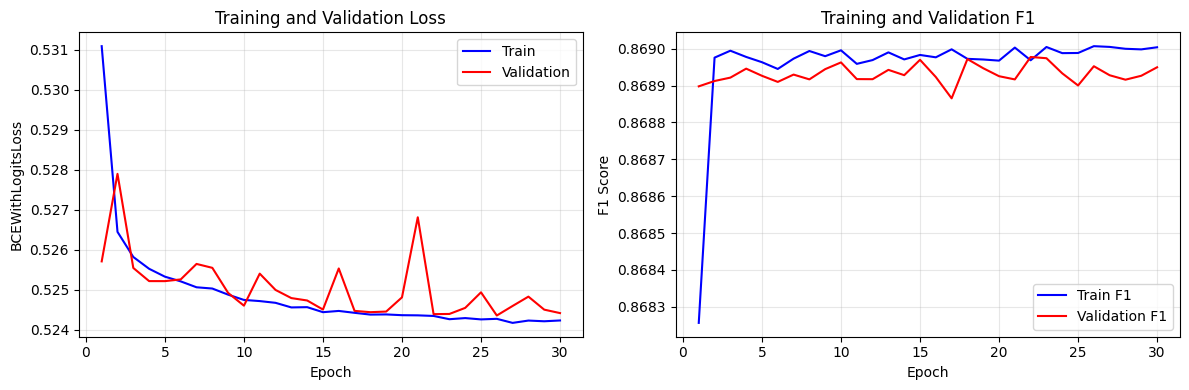

Saved training_curves.png


In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss curves
ax1.plot(epochs_range, history['train_loss'], label='Train', color='blue')
ax1.plot(epochs_range, history['val_loss'], label='Validation', color='red')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCEWithLogitsLoss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# F1 curves
ax2.plot(epochs_range, history['train_f1'], label='Train F1', color='blue')
ax2.plot(epochs_range, history['val_f1'], label='Validation F1', color='red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 Score')
ax2.set_title('Training and Validation F1')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_curves.png')

#### d) Evaluation — Neural Network vs Scikit-learn Models

In [23]:
# Collect predictions on validation set using best checkpoint
_, v_labels, v_preds, v_proba = run_epoch(val_loader, model, criterion)

nn_acc = accuracy_score(v_labels, v_preds)
nn_f1 = f1_score(v_labels, v_preds, zero_division=0)
nn_auc = roc_auc_score(v_labels, v_proba)

print('=' * 65)
print(f"{'MODEL COMPARISON — VALIDATION SET':^65}")
print('=' * 65)
print(f"{'Model':<35} {'F1':>8} {'AUC-ROC':>10} {'Accuracy':>10}")
print('-' * 65)

# Scikit-learn results from earlier cells
for r in clf_results:
    print(f"{r['Model']:<35} {r['F1']:>8.4f} {r['AUC-ROC']:>10.4f} {r['Accuracy']:>10.4f}")

# Tuned RF
tuned_preds = best_model.predict(X_val)
tuned_proba = best_model.predict_proba(X_val)[:, 1]
print(f"{'Random Forest (tuned)':<35} "
      f"{f1_score(y_val, tuned_preds, zero_division=0):>8.4f} "
      f"{roc_auc_score(y_val, tuned_proba):>10.4f} "
      f"{accuracy_score(y_val, tuned_preds):>10.4f}")

# Neural network
print(f"{'Neural Network (PyTorch)':<35} {nn_f1:>8.4f} {nn_auc:>10.4f} {nn_acc:>10.4f}")
print('=' * 65)

print(f'\nNeural network final metrics on validation set:')
print(f'  Accuracy : {nn_acc:.4f}')
print(f'  F1 Score : {nn_f1:.4f}')
print(f'  AUC-ROC  : {nn_auc:.4f}')

                MODEL COMPARISON — VALIDATION SET                
Model                                     F1    AUC-ROC   Accuracy
-----------------------------------------------------------------
Logistic Regression                   0.8687     0.6089     0.7709
Random Forest Classifier              0.8656     0.5889     0.7672
Random Forest (tuned)                 0.7022     0.6167     0.6008
Neural Network (PyTorch)              0.8690     0.6178     0.7710

Neural network final metrics on validation set:
  Accuracy : 0.7710
  F1 Score : 0.8690
  AUC-ROC  : 0.6178


---

## Part 3: Model Evaluations & Interpretation

### 7. Comprehensive Evaluation

#### a) Summary Table

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

# Collect test-set classification predictions from all models
def clf_test_metrics(name, model, X, y):
    preds = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y, preds),
        'Precision': precision_score(y, preds, zero_division=0),
        'Recall': recall_score(y, preds, zero_division=0),
        'F1': f1_score(y, preds, zero_division=0),
        'AUC-ROC': roc_auc_score(y, proba),
        '_preds': preds,
        '_proba': proba,
    }

clf_test = [
    clf_test_metrics('Logistic Regression', log_reg, X_test, y_test),
    clf_test_metrics('Random Forest (baseline)', rf_clf, X_test, y_test),
    clf_test_metrics('Random Forest (tuned)', best_model, X_test, y_test),
]

# Neural network on test set
_, nn_labels, nn_preds, nn_proba = run_epoch(test_loader, model, criterion)
clf_test.append({
    'Model': 'Neural Network',
    'Accuracy': accuracy_score(nn_labels, nn_preds),
    'Precision': precision_score(nn_labels, nn_preds, zero_division=0),
    'Recall': recall_score(nn_labels, nn_preds, zero_division=0),
    'F1': f1_score(nn_labels, nn_preds, zero_division=0),
    'AUC-ROC': roc_auc_score(nn_labels, nn_proba),
    '_preds': np.array(nn_preds),
    '_proba': np.array(nn_proba),
})

# Classification summary table
print('=' * 78)
print(f"{'CLASSIFICATION — TEST SET':^78}")
print('=' * 78)
print(f"{'Model':<30} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC-ROC':>9}")
print('-' * 78)
for r in clf_test:
    print(f"{r['Model']:<30} {r['Accuracy']:>9.4f} {r['Precision']:>10.4f} " f"{r['Recall']:>8.4f} {r['F1']:>8.4f} {r['AUC-ROC']:>9.4f}")
print('=' * 78)

# Regression test metrics
def reg_test_metrics(name, model, X, y):
    preds = model.predict(X)
    return {
        'Model': name,
        'MAE': mean_absolute_error(y, preds),
        'RMSE': np.sqrt(mean_squared_error(y, preds)),
        'R2': r2_score(y, preds),
        '_preds': preds,
    }

y_test_reg = df_pd.loc[X_test.index, 'tip_amount']
reg_test = [
    reg_test_metrics('Linear Regression', lr, X_test, y_test_reg),
    reg_test_metrics('Random Forest Regressor', rf, X_test, y_test_reg),
]

print()
print('=' * 55)
print(f"{'REGRESSION — TEST SET':^55}")
print('=' * 55)
print(f"{'Model':<30} {'MAE':>7} {'RMSE':>7} {'R2':>7}")
print('-' * 55)
for r in reg_test:
    print(f"{r['Model']:<30} ${r['MAE']:>5.4f} ${r['RMSE']:>5.4f} {r['R2']:>7.4f}")
print('=' * 55)

                          CLASSIFICATION — TEST SET                           
Model                           Accuracy  Precision   Recall       F1   AUC-ROC
------------------------------------------------------------------------------
Logistic Regression               0.7710     0.7692   0.9979   0.8687    0.6111
Random Forest (baseline)          0.7673     0.7705   0.9876   0.8657    0.5915
Random Forest (tuned)             0.6027     0.8109   0.6218   0.7039    0.6194
Neural Network                    0.7711     0.7685   0.9997   0.8690    0.6209

                 REGRESSION — TEST SET                 
Model                              MAE    RMSE      R2
-------------------------------------------------------
Linear Regression              $1.2049 $2.3451  0.6252
Random Forest Regressor        $1.2109 $2.3433  0.6258


#### b) ROC Curves — All Classification Models

ROC curves show the trade-off between true positive rate and false positive rate at every classification threshold. A larger area under the curve (AUC) means better class separation ability across all thresholds.

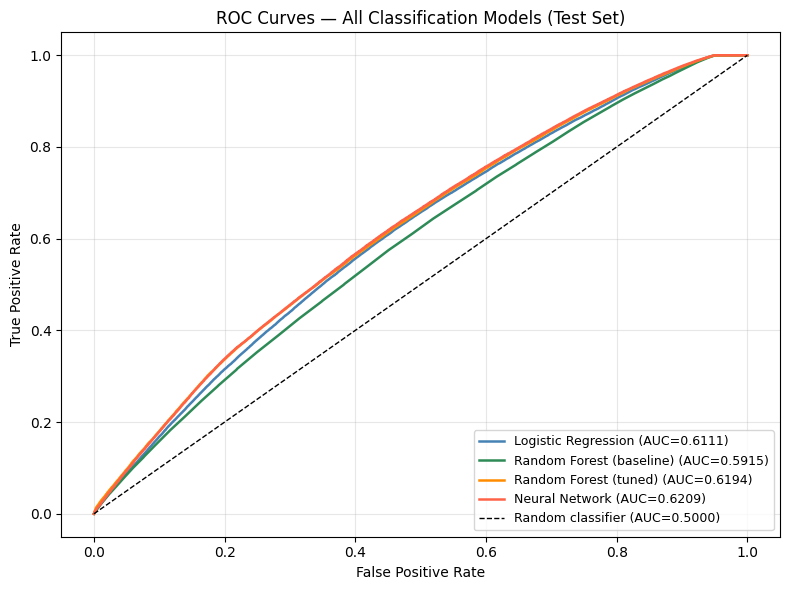

Saved roc_curves.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['steelblue', 'seagreen', 'darkorange', 'tomato']

for r, color in zip(clf_test, colors):
    fpr, tpr, _ = roc_curve(
        y_test if r['Model'] != 'Neural Network' else nn_labels, r['_proba']
    )
    ax.plot(fpr, tpr, color=color, lw=1.8,label=f"{r['Model']} (AUC={r['AUC-ROC']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC=0.5000)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Classification Models (Test Set)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved roc_curves.png')

#### b) Confusion Matrix — Best Classification Model

The best model is selected by highest AUC-ROC on the test set. The confusion matrix shows true/false positives and negatives, giving a clearer picture of error types than accuracy alone.

Best classification model: Neural Network (AUC-ROC=0.6209)


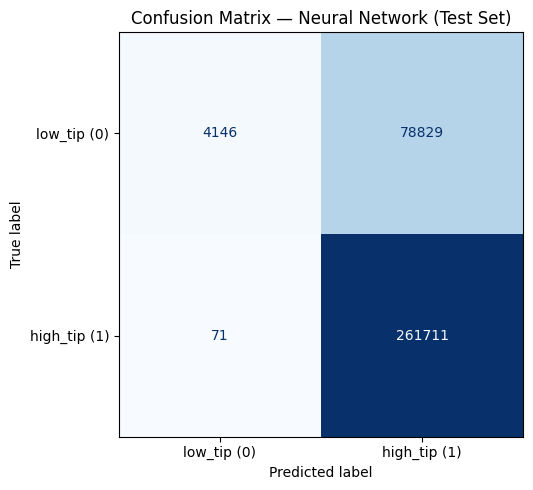

True Negatives  (correctly predicted low tip)  : 4,146
False Positives (low tip predicted as high)    : 78,829
False Negatives (high tip predicted as low)    : 71
True Positives  (correctly predicted high tip) : 261,711

Precision : 0.7685
Recall    : 0.9997


In [26]:
# Identify best classification model by AUC-ROC
best_clf = max(clf_test, key=lambda r: r['AUC-ROC'])
print(f"Best classification model: {best_clf['Model']} (AUC-ROC={best_clf['AUC-ROC']:.4f})")

true_labels = np.array(nn_labels if best_clf['Model'] == 'Neural Network' else y_test)

cm = confusion_matrix(true_labels, best_clf['_preds'])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['low_tip (0)', 'high_tip (1)']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_clf["Model"]} (Test Set)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly predicted low tip)  : {tn:,}')
print(f'False Positives (low tip predicted as high)    : {fp:,}')
print(f'False Negatives (high tip predicted as low)    : {fn:,}')
print(f'True Positives  (correctly predicted high tip) : {tp:,}')
print(f'\nPrecision : {tp / (tp + fp):.4f}')
print(f'Recall    : {tp / (tp + fn):.4f}')

#### c) Regression - Predicted vs Actual Tip Amounts

The best regression model (by R2) is plotted against ground truth. A perfect model would have all points on the diagonal. Systematic deviations reveal bias; spread around the diagonal reveals variance.

Best regression model: Random Forest Regressor (R2=0.6258)
Axis clipped at $18.87 (99th percentile of actual values)
Outliers excluded from plot: 3,295 (0.96% of test set)


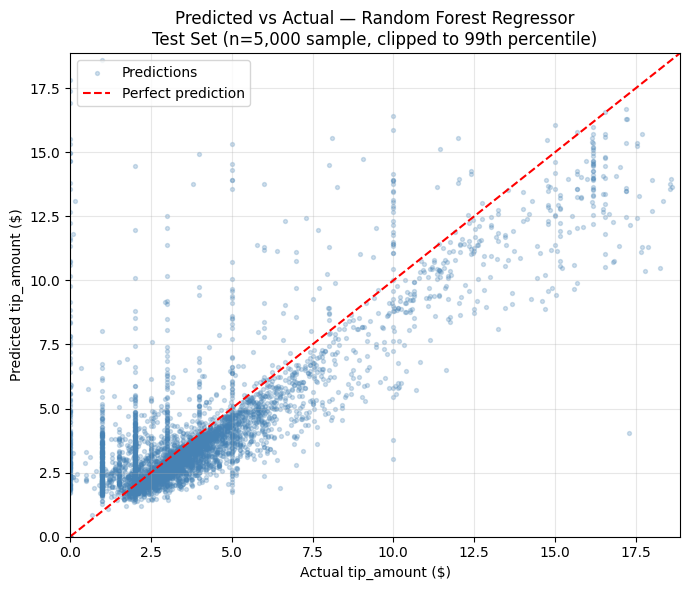

Saved pred_vs_actual.png


In [31]:
# Identify best regression model by R2
best_reg = max(reg_test, key=lambda r: r['R2'])
print(f"Best regression model: {best_reg['Model']} (R2={best_reg['R2']:.4f})")

y_true_arr = y_test_reg.values
y_pred_arr = best_reg['_preds']

# Clip axes to 99th percentile of actual values to prevent extreme outliers
# from collapsing the main data cluster into the bottom-left corner
p99_actual = np.percentile(y_true_arr, 99)
p99_pred = np.percentile(y_pred_arr, 99)
axis_max = max(p99_actual, p99_pred) * 1.05

# Sample only points within the visible range for clarity
in_range = (y_true_arr <= axis_max) & (y_pred_arr <= axis_max)
y_true_plot = y_true_arr[in_range]
y_pred_plot = y_pred_arr[in_range]

rng = np.random.default_rng(42)
sample_idx = rng.choice(len(y_true_plot), size=min(5000, len(y_true_plot)), replace=False)

print(f'Axis clipped at ${axis_max:.2f} (99th percentile of actual values)')
print(f'Outliers excluded from plot: {(~in_range).sum():,} '
      f'({(~in_range).mean()*100:.2f}% of test set)')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_true_plot[sample_idx], y_pred_plot[sample_idx],
           alpha=0.25, s=8, color='steelblue', label='Predictions')

ax.plot([0, axis_max], [0, axis_max], 'r--', lw=1.5, label='Perfect prediction')

ax.set_xlim(0, axis_max)
ax.set_ylim(0, axis_max)
ax.set_xlabel('Actual tip_amount ($)')
ax.set_ylabel('Predicted tip_amount ($)')
ax.set_title(
    f'Predicted vs Actual — {best_reg["Model"]}\n'
    f'Test Set (n=5,000 sample, clipped to 99th percentile)'
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved pred_vs_actual.png')

#### d) Residual Analysis — Best Regression Model

Residuals are `actual - predicted`. A well-specified model should have residuals that are centred at zero with no systematic pattern against fitted values. Patterns (fan shape, curvature) indicate heteroscedasticity or missing structure.

Residual summary:
  Mean   : $  0.0255  (should be near 0)
  Std    : $  2.3432
  Min    : $-55.6007
  Max    : $216.4609
  Within +/-$1 : 64.0%
  Within +/-$2 : 83.8%
  Within +/-$5 : 96.6%


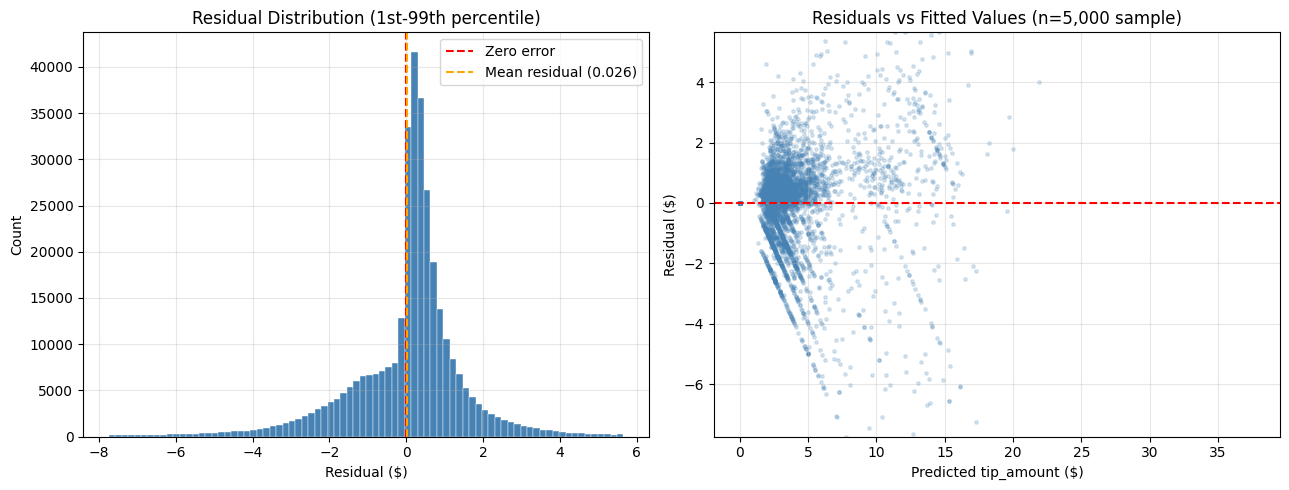

Saved residual_analysis.png


In [34]:
residuals = y_true_arr - y_pred_arr

print('Residual summary:')
print(f'  Mean   : ${residuals.mean():>8.4f}  (should be near 0)')
print(f'  Std    : ${residuals.std():>8.4f}')
print(f'  Min    : ${residuals.min():>8.4f}')
print(f'  Max    : ${residuals.max():>8.4f}')
pct_within_1 = (np.abs(residuals) < 1).mean() * 100
pct_within_2 = (np.abs(residuals) < 2).mean() * 100
pct_within_5 = (np.abs(residuals) < 5).mean() * 100
print(f'  Within +/-$1 : {pct_within_1:.1f}%')
print(f'  Within +/-$2 : {pct_within_2:.1f}%')
print(f'  Within +/-$5 : {pct_within_5:.1f}%')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: residual distribution clipped to 1st-99th percentile
clip_lo = np.percentile(residuals, 1)
clip_hi = np.percentile(residuals, 99)
res_clipped = residuals[(residuals >= clip_lo) & (residuals <= clip_hi)]

ax1.hist(res_clipped, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
ax1.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
ax1.axvline(residuals.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'Mean residual ({residuals.mean():.3f})')
ax1.set_xlabel('Residual ($)')
ax1.set_ylabel('Count')
ax1.set_title('Residual Distribution (1st-99th percentile)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: residuals vs fitted values
# Draw a fresh 5000-point sample directly from y_pred_arr / residuals
rng2 = np.random.default_rng(99)
res_sample_idx = rng2.choice(len(residuals), size=min(5000, len(residuals)), replace=False)

ax2.scatter(y_pred_arr[res_sample_idx], residuals[res_sample_idx], alpha=0.2, s=6, color='steelblue')
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Predicted tip_amount ($)')
ax2.set_ylabel('Residual ($)')
ax2.set_title('Residuals vs Fitted Values (n=5,000 sample)')
ax2.set_ylim(clip_lo, clip_hi)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved residual_analysis.png')

---

### 8. Feature Importance

Two complementary methods are used: impurity-based importances from the Random Forest (how much each feature reduces weighted Gini impurity on average across all trees) and standardised coefficients from Logistic Regression (the log-odds change per one standard-deviation shift in each feature).

#### a) Random Forest feature importances (tuned model)

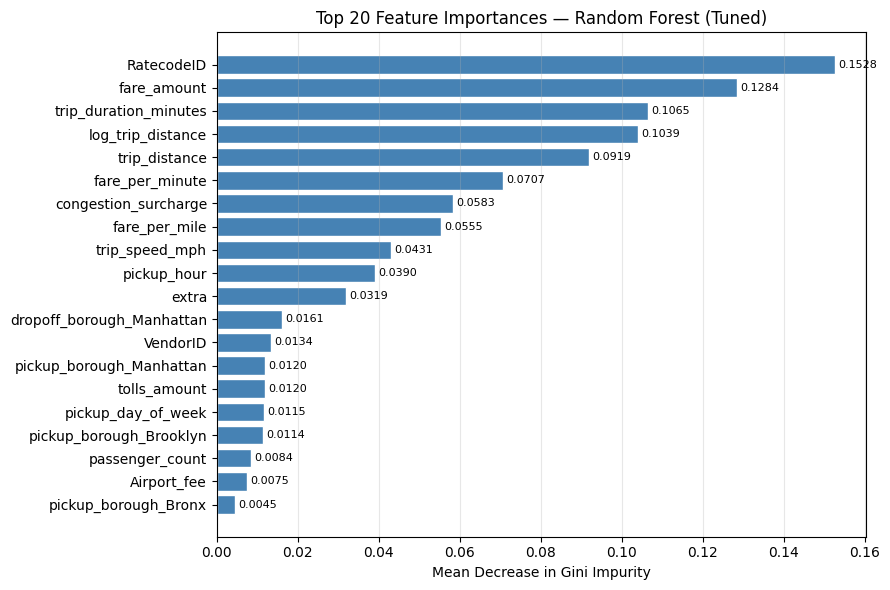

Top 10 features by Random Forest importance:
Rank   Feature                               Importance
--------------------------------------------------------
1      RatecodeID                                0.1528
2      fare_amount                               0.1284
3      trip_duration_minutes                     0.1065
4      log_trip_distance                         0.1039
5      trip_distance                             0.0919
6      fare_per_minute                           0.0707
7      congestion_surcharge                      0.0583
8      fare_per_mile                             0.0555
9      trip_speed_mph                            0.0431
10     pickup_hour                               0.0390


In [32]:
importances = best_model.feature_importances_
feature_names = X_train.columns.tolist()

# Sort descending: index 0 = most important
order = np.argsort(importances)[::-1]
top_n = 20
top_names = [feature_names[i] for i in order[:top_n]]
top_vals = importances[order[:top_n]]

# Plot: reverse both so most important appears at the top of the horizontal chart
plot_names = top_names[::-1]   # least important first (bottom of chart)
plot_vals = top_vals[::-1]     # matching values, same order

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(plot_names, plot_vals, color='steelblue', edgecolor='white')
ax.set_xlabel('Mean Decrease in Gini Impurity')
ax.set_title(f'Top {top_n} Feature Importances — Random Forest (Tuned)')
ax.grid(True, alpha=0.3, axis='x')

# Annotate each bar with its own value — bars[i] corresponds to plot_vals[i]
for bar, val in zip(bars, plot_vals):
    ax.text(
        val + ax.get_xlim()[1] * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}', va='center', fontsize=8
    )

plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features by Random Forest importance:')
print(f"{'Rank':<6} {'Feature':<35} {'Importance':>12}")
print('-' * 56)
for rank, (name, val) in enumerate(zip(top_names[:10], top_vals[:10]), 1):
    print(f"{rank:<6} {name:<35} {val:>12.4f}")

#### b) Logistic Regression standardised coefficients

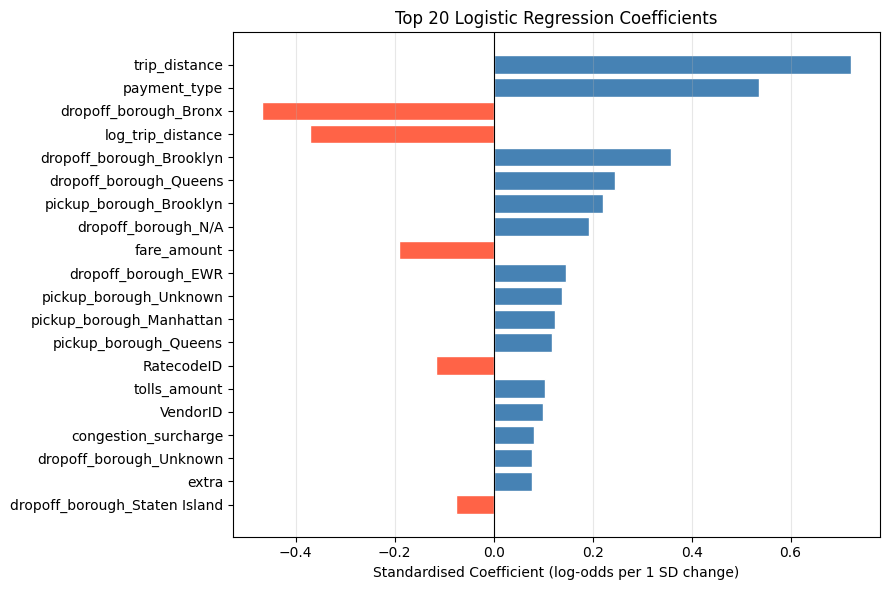

Top 10 features by absolute Logistic Regression coefficient:
Rank   Feature                              Coefficient  Direction
--------------------------------------------------------------------
1      trip_distance                             0.7212 increases high_tip
2      payment_type                              0.5369 increases high_tip
3      dropoff_borough_Bronx                    -0.4674 decreases high_tip
4      log_trip_distance                        -0.3717 decreases high_tip
5      dropoff_borough_Brooklyn                  0.3582 increases high_tip
6      dropoff_borough_Queens                    0.2461 increases high_tip
7      pickup_borough_Brooklyn                   0.2215 increases high_tip
8      dropoff_borough_N/A                       0.1926 increases high_tip
9      fare_amount                              -0.1914 decreases high_tip
10     dropoff_borough_EWR                       0.1468 increases high_tip


In [30]:
coef = log_reg.coef_[0]
coef_series = sorted(zip(feature_names, coef), key=lambda x: abs(x[1]), reverse=True)
top_coef = coef_series[:20]

names_c = [x[0] for x in top_coef]
vals_c = [x[1] for x in top_coef]
colors_c = ['tomato' if v < 0 else 'steelblue' for v in vals_c]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(names_c[::-1], vals_c[::-1], color=colors_c[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardised Coefficient (log-odds per 1 SD change)')
ax.set_title('Top 20 Logistic Regression Coefficients')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('logreg_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features by absolute Logistic Regression coefficient:')
print(f"{'Rank':<6} {'Feature':<35} {'Coefficient':>12} {'Direction':>10}")
print('-' * 68)
for rank, (name, val) in enumerate(coef_series[:10], 1):
    direction = 'increases high_tip' if val > 0 else 'decreases high_tip'
    print(f"{rank:<6} {name:<35} {val:>12.4f} {direction:>18}")

---

## AI Assistance Disclosure

Parts of this notebook were developed with assistance from an AI coding assistant (Claude, Anthropic). Assistance was used for: debugging Polars syntax errors, structuring the PyTorch training loop, formatting output tables and formatting graphs. All modelling decisions, hyperparameter choices, and written analysis are my own.